In [1]:
pip install tensorflow


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as n
import matplotlib.pyplot as plt


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data() #Loading the MNIST dataset from keras

In [5]:
x_train[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [6]:
y_test[1]

np.uint8(2)

In [7]:
x_test[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 116, 125, 171,
        255, 255, 150,  93,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 169, 253, 253, 253,
        253, 253, 253, 218,  30,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 169, 253, 253, 253, 213,
        142, 176, 253, 253, 122,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [8]:
y_test[1]

np.uint8(2)

In [10]:
x_train.shape

(60000, 28, 28)

In [11]:
y_train.shape

(60000,)

In [12]:
x_test.shape

(10000, 28, 28)

In [13]:
y_test.shape

(10000,)

Model - **ANN**

In [ ]:
model = models.Sequential([
    layers.Flatten(input_shape=(28,28)), #input later (flatten - converts 2D array to 1D array)
    layers.Dense(128, activation='relu'), #hidden layer (pixels connected to 128 neurons with relu activation)
    layers.Dense(10, activation='softmax') #output layer (10 neurons with softmax activation - probability of getting a digit)
])

/Users/srihitha_g/Documents/tensorflowProj/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) # compiling with activation function and loss function.

***Training The Model***

In [27]:
training = model.fit(x_train, y_train, epochs=5) # For every epoch entire dataset is passed once each.

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 569us/step - accuracy: 0.9457 - loss: 0.2195
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 566us/step - accuracy: 0.9499 - loss: 0.2059
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 571us/step - accuracy: 0.9537 - loss: 0.1897
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 592us/step - accuracy: 0.9552 - loss: 0.1908
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 573us/step - accuracy: 0.9561 - loss: 0.1863


In [19]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step - accuracy: 0.9408 - loss: 0.2542


In [20]:
predictions = model.predict(x_test)
print(predictions)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 283us/step
[[2.1941641e-24 1.0163887e-14 4.3758994e-10 ... 9.9999714e-01
  1.1105985e-12 2.8797813e-06]
 [1.8031488e-11 2.3089172e-03 9.9764872e-01 ... 3.0805339e-05
  4.2281907e-11 1.5733888e-22]
 [2.8125441e-10 9.9927807e-01 6.4790336e-04 ... 6.6170935e-05
  7.4408294e-06 3.4815754e-15]
 ...
 [2.7483251e-27 2.8750914e-21 6.6991544e-15 ... 7.0934300e-12
  9.7757826e-13 4.4736530e-11]
 [7.2037894e-18 5.3633712e-20 9.1831737e-10 ... 3.0020573e-11
  3.2480770e-05 9.9987142e-07]
 [9.3262897e-12 1.8563240e-24 4.6096313e-09 ... 5.4624511e-25
  3.4280265e-12 3.7416050e-16]]


In [21]:
print(predictions.shape)

(10000, 10)


In [24]:
predictions[9]

array([3.4268250e-17, 5.2045916e-11, 1.4662857e-06, 8.0469862e-04,
       8.1468159e-03, 2.7639760e-06, 5.1479566e-20, 1.6602356e-03,
       2.8027205e-05, 9.8935604e-01], dtype=float32)

In [25]:
y_test[9]

np.uint8(9)

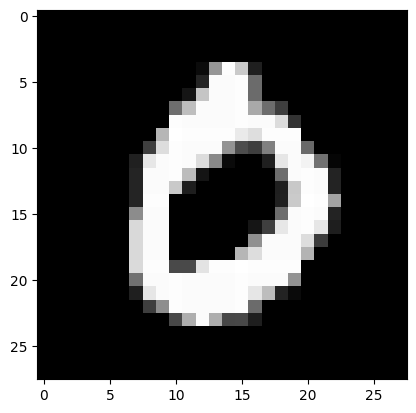

In [26]:
plt.imshow(x_test[3], cmap='gray')

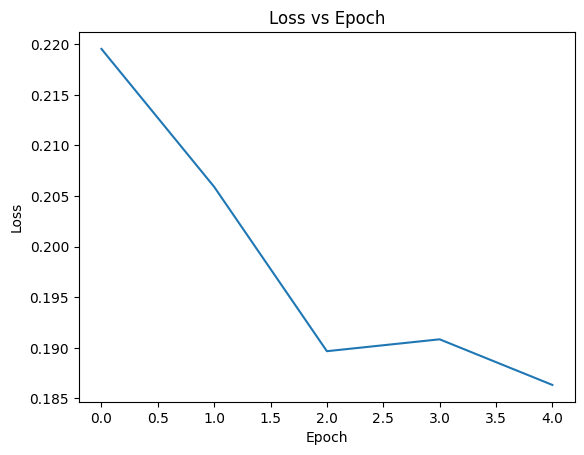

In [29]:
plt.plot(training.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.show()

The plot shows training loss steadily decreasing over the epochs. 
Dropping from 0.22 to 0.186, which means the model is learning.
Uptick at 3rd epoch should be noise from training, but the overall trend is downward.